**FYP Phishing Detection 3.0**

This verion using the improvised dataset with 111,995 Legitimate URL gathered from browser history and 76,691 Phishing URL covering 22 features to experiment trained model detecting the legitimate URL better

In [13]:
# importing libraries
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
import joblib

In [14]:
import matplotlib.pyplot as plt
import warnings

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings('ignore')

In [15]:
# Importing the dataset
# dataset version 3 with 287612 unique URLs 
dataset_original = pd.read_csv(r"D:\FYP AMIRA\FYP Phishing Detection 3.0\Dataset\dataset_v3.csv")

Data Preprocessing

In [16]:
before = len(dataset_original)
dataset = dataset_original.drop_duplicates(subset=['url']).reset_index(drop=True)
after = len(dataset)

print(f"Rows before: {before}")
print(f"Rows after : {after}")
print(f"Duplicates removed: {before - after}")

Rows before: 347589
Rows after : 346220
Duplicates removed: 1369


In [17]:
#misisng values
print(dataset.isnull().sum())

url                 0
url_len             0
dom                 0
dom_len             0
is_ip               0
tld             11624
tld_len             0
subdom_cnt          0
letter_cnt          0
digit_cnt           0
special_cnt         0
eq_cnt              0
qm_cnt              0
amp_cnt             0
dot_cnt             0
dash_cnt            0
under_cnt           0
letter_ratio        0
digit_ratio         0
spec_ratio          0
is_https            0
slash_cnt           0
entropy             0
path_len            0
query_len           0
label               0
dtype: int64


In [18]:
#dataset.to_csv(
 #   r"D:\FYP AMIRA\FYP Phishing Detection 3.0\Dataset\dataset_v3.csv",
  #  index=False
#)

In [19]:
#Encoding categorical columns
#dataset contains object type columns, converted into numeric form using Label Encoding so that the machine learning model can process 
#label_encoder = LabelEncoder()

#for col in dataset.select_dtypes(include=['object']).columns:
    #dataset[col] = label_encoder.fit_transform(dataset[col])

#print(dataset.head())

In [20]:
# X represents the input variables (features)
# Drop label (target) and unnecessary text columns
X = dataset.drop(columns=['label', 'url', 'dom', 'tld'])

# y represents the target variable
# 0 = Legitimate URL
# 1 = Phishing URL
y = dataset["label"]

print(X.head())

   url_len  dom_len  is_ip  tld_len  subdom_cnt  letter_cnt  digit_cnt  \
0       24       11      0        6           1          17          0   
1       26       14      0        6           1          19          0   
2       23       10      0        6           1          16          0   
3       19       11      0        6           0          13          0   
4       22       10      0        6           1          15          0   

   special_cnt  eq_cnt  qm_cnt  ...  dash_cnt  under_cnt  letter_ratio  \
0            7       0       0  ...         0          0      0.708333   
1            7       0       0  ...         0          0      0.730769   
2            7       0       0  ...         0          0      0.695652   
3            6       0       0  ...         0          0      0.684211   
4            7       0       0  ...         0          0      0.681818   

   digit_ratio  spec_ratio  is_https  slash_cnt   entropy  path_len  query_len  
0          0.0    0.291667   

In [21]:
#Split dataset 70/30 into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)
# Display sizes
print("Training Set:", len(X_train))
print("Testing Set:", len(X_test))

print("\nTraining Labels:")
print(y_train.value_counts())

print("\nTesting Labels:")
print(y_test.value_counts())

Training Set: 242354
Testing Set: 103866

Training Labels:
label
1    123914
0    118440
Name: count, dtype: int64

Testing Labels:
label
1    53106
0    50760
Name: count, dtype: int64


Random Forest Model

In [22]:
# Applying grid search to find best performing parameters 
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV #for optimizing hyperparameters

# Define the parameter grid to search over (different combinations)
parameters = [{
    'n_estimators': [100, 700],       # Number of trees in the forest
    'max_features': ['sqrt', 'log2'], # Number of features considered at each split
    'criterion': ['gini', 'entropy'], # Splitting criterion
    'max_depth': [None, 10, 20, 30],
    'bootstrap': [True]
}]

In [23]:
grid_search = RandomizedSearchCV(
    RandomForestClassifier(),
    param_distributions=parameters,
    n_iter=20,        # Only test 20 combinations (NOT all)
    cv=3,             # reduce folds
    n_jobs=-1,
    random_state=0
)#GridSearchCV(RandomForestClassifier(), parameters, cv=5, n_jobs=-1)
grid_search.fit(X_train, y_train)

accuracy = grid_search.best_score_
print("Best Accuracy =", str(accuracy* 100), " %")

# Printing best parameters 
print("Best parameters =", str(grid_search.best_params_))

Best Accuracy = 95.74217918774913  %
Best parameters = {'n_estimators': 700, 'max_features': 'sqrt', 'max_depth': 20, 'criterion': 'entropy', 'bootstrap': True}


In [24]:
#classifier = grid_search.best_estimator_
# Fitting RandomForest regression with best params 
best_params = grid_search.best_params_
classifier = RandomForestClassifier(n_estimators=best_params['n_estimators'], 
                                    criterion=best_params['criterion'], 
                                    max_features=best_params['max_features'], 
                                     class_weight='balanced', 
                                    random_state=0)
classifier.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",700
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'entropy'
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",0
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 

In [26]:
# Make predictions
y_pred = classifier.predict(X_test)

In [27]:
# Evaluate performance
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

In [28]:
print("PERFORMANCE FYP Phishing Detection 3.0")
print(f"\nAccuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

PERFORMANCE FYP Phishing Detection 3.0

Accuracy: 0.9578

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.96      0.96     50760
           1       0.96      0.96      0.96     53106

    accuracy                           0.96    103866
   macro avg       0.96      0.96      0.96    103866
weighted avg       0.96      0.96      0.96    103866


Confusion Matrix:
[[48537  2223]
 [ 2155 50951]]


In [ ]:
#import joblib

#joblib.dump(classifier, "rf_model_v3.pkl")

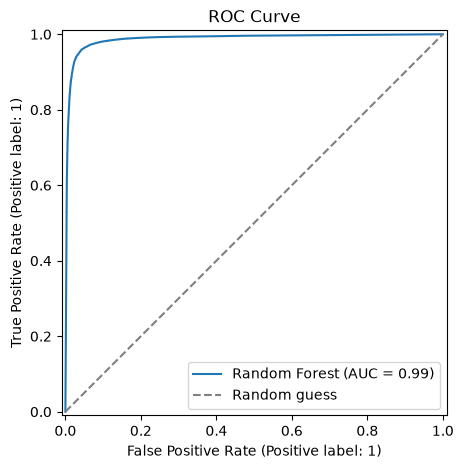

AUC Score: 0.9876


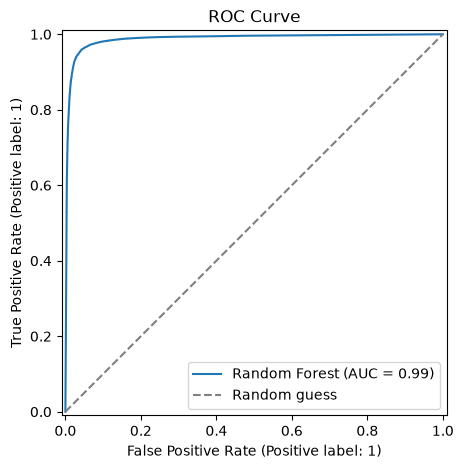

AUC Score: 0.9876


In [ ]:
from sklearn.metrics import RocCurveDisplay, roc_auc_score
import matplotlib.pyplot as plt

y_proba = classifier.predict_proba(X_test)[:, 1]  # probability of being phishing

fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_test, y_proba, name='Random Forest', ax=ax)
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guess')
plt.title('ROC Curve')
plt.legend()
plt.savefig('roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"AUC Score: {roc_auc_score(y_test, y_proba):.4f}")

fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_test, y_proba, name='Random Forest', ax=ax)
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guess')
plt.title('ROC Curve')
plt.legend()
plt.savefig('roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"AUC Score: {roc_auc_score(y_test, y_proba):.4f}")

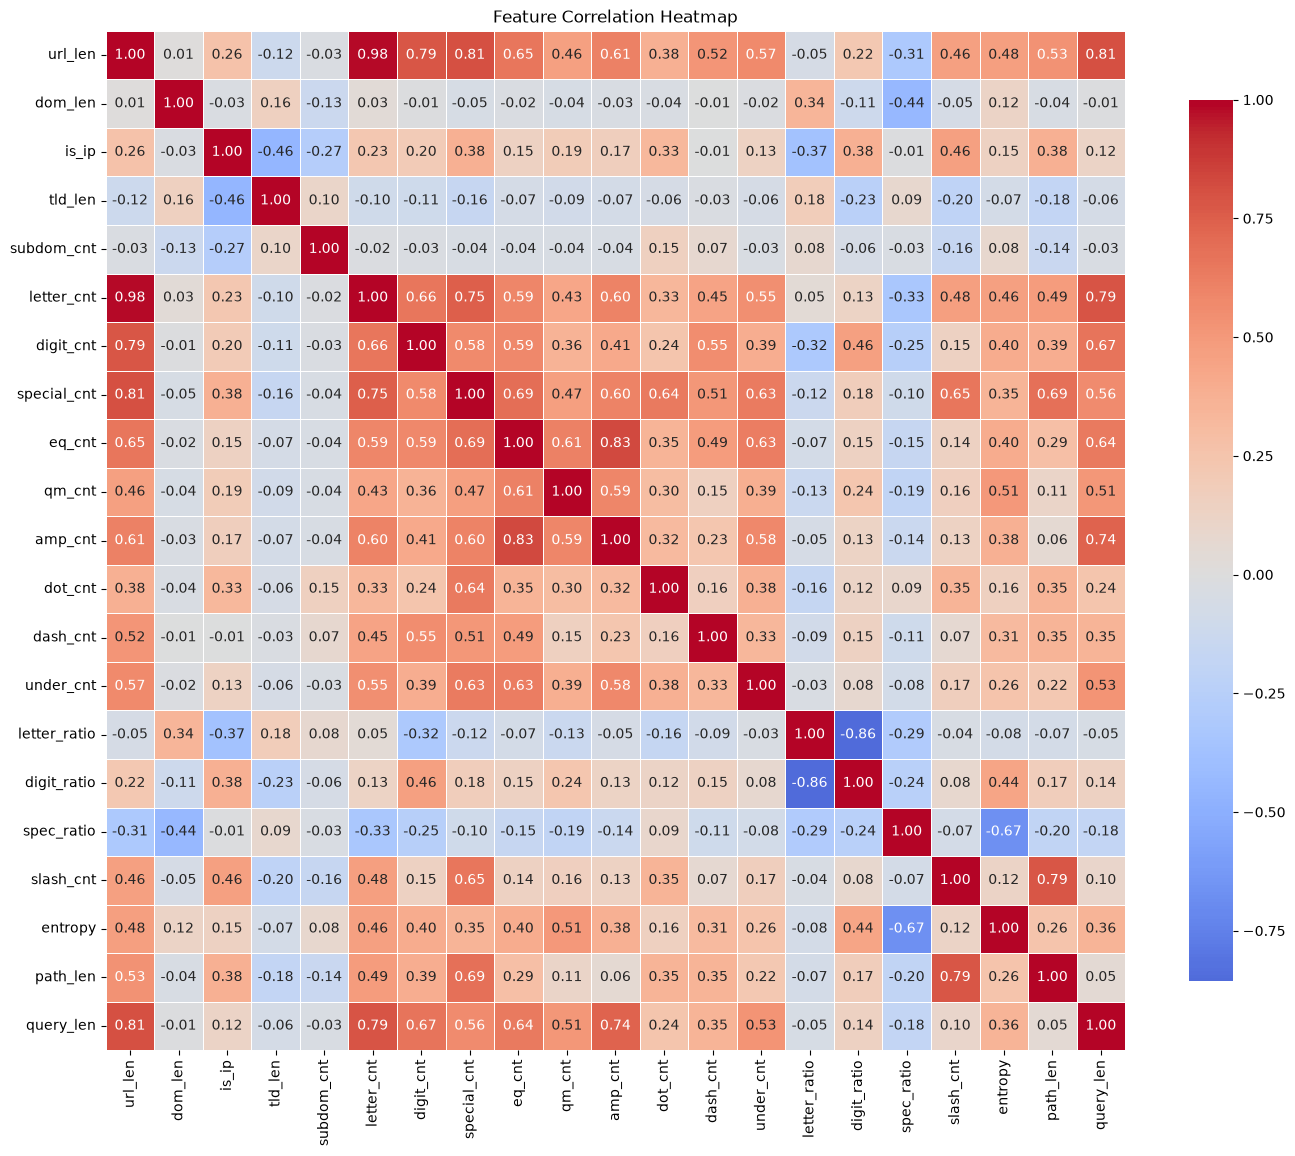

In [ ]:


import seaborn as sns

FEATURE_COLUMNS = ['url_len','dom_len','is_ip','tld_len','subdom_cnt','letter_cnt','digit_cnt',
                    'special_cnt','eq_cnt','qm_cnt','amp_cnt','dot_cnt','dash_cnt','under_cnt',
                    'letter_ratio','digit_ratio','spec_ratio','slash_cnt','entropy','path_len','query_len']

corr_matrix = X[FEATURE_COLUMNS].corr()

plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('feature_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [29]:
from sklearn.metrics import confusion_matrix

y_pred = classifier.predict(X_test)   # use your actual Model 3.0 classifier variable name
cm = confusion_matrix(y_test, y_pred)
print(cm)  # sanity check — should show [[48537, 2223],[2155, 50951]] or close to it

[[48537  2223]
 [ 2155 50951]]


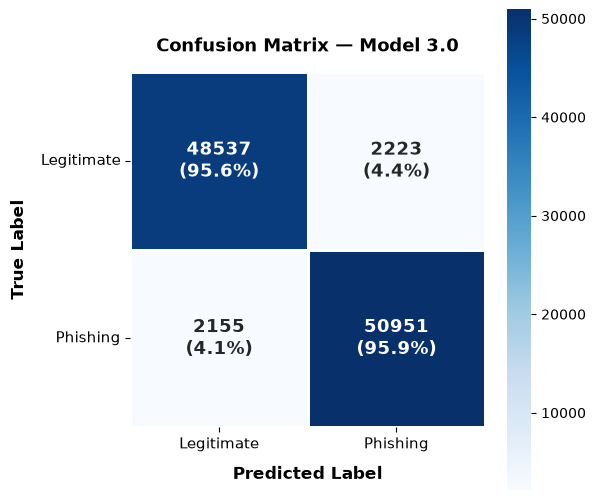

In [30]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Your Model 3.0 confusion matrix values
cm = np.array([[48537, 2223],
               [2155, 50951]])

# Row-normalize to get percentages (% within each true class)
cm_percent = cm.astype('float') / cm.sum(axis=1, keepdims=True) * 100

# Combine count + percentage into one annotation per cell
labels = np.array([f"{count}\n({pct:.1f}%)"
                    for count, pct in zip(cm.flatten(), cm_percent.flatten())]).reshape(2, 2)

fig, ax = plt.subplots(figsize=(6, 5.5))
sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', cbar=True,
            xticklabels=['Legitimate', 'Phishing'],
            yticklabels=['Legitimate', 'Phishing'],
            annot_kws={'size': 13, 'weight': 'bold'},
            linewidths=1, linecolor='white', square=True, ax=ax)

ax.set_xlabel('Predicted Label', fontsize=12, weight='bold', labelpad=10)
ax.set_ylabel('True Label', fontsize=12, weight='bold', labelpad=10)
ax.set_title('Confusion Matrix — Model 3.0', fontsize=13, weight='bold', pad=15)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11, rotation=0)

plt.tight_layout()
plt.savefig('confusion_matrix_model3.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': classifier.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False,
)

feature_importance

feature_importance.sort_values(
    by='Importance',
    ascending=False,
)

NameError: name 'dataset' is not defined